# 02. Augmentation Ablation (E1)

**Research question:** does training-time augmentation improve generalisation, and in particular
does it close the gap between `lab` (studio, controlled lighting) and `field` (real-world, phone
camera) test performance?

**Controlled setup.** Both runs below use the exact same custom CNN (`src/models/baseline_cnn.py`),
the same locked `data/splits/{train,val,test}.csv` (7,395 images, 30 classes), the same seed (42),
and identical hyperparameters (image size 128, batch size 32, AdamW lr=1e-3, weight_decay=1e-4,
10 epochs). **The only thing that changes between the two runs is whether training-time augmentation
(`src/data/transforms.py`: random crop, horizontal flip, brightness/contrast jitter) is enabled.**
Validation/test transforms are always deterministic (resize + center pad, no randomness) for both
runs, so the comparison is fair.

## Training commands

Training itself runs through the shared trainer (`src/training/trainer.py`, via
`part1_custom_cnn.py`) rather than inside this notebook, since each run takes several minutes and
the trainer already writes standardized `metrics.csv` / `summary.json` / `best_custom_cnn.pt`
outputs. The two commands below are exactly what produced the results loaded further down:

```bash
python3 part1_custom_cnn.py --use-splits --split-dir data/splits --no-augmentation \
  --epochs 10 --batch-size 32 --image-size 128 --learning-rate 0.001 --weight-decay 0.0001 \
  --seed 42 --output-dir outputs/part2_augmentation/no_aug

python3 part1_custom_cnn.py --use-splits --split-dir data/splits \
  --epochs 10 --batch-size 32 --image-size 128 --learning-rate 0.001 --weight-decay 0.0001 \
  --seed 42 --output-dir outputs/part2_augmentation/aug
```

This cell loads the resulting `metrics.csv` histories for both runs directly from
`outputs/part2_augmentation/`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

no_aug_history = pd.read_csv(REPO_ROOT / "outputs/part2_augmentation/no_aug/metrics.csv")
aug_history = pd.read_csv(REPO_ROOT / "outputs/part2_augmentation/aug/metrics.csv")

no_aug_history["variant"] = "no_augmentation"
aug_history["variant"] = "augmentation"
history = pd.concat([no_aug_history, aug_history], ignore_index=True)
history.pivot(index="epoch", columns="variant", values="val_acc")

variant,augmentation,no_augmentation
epoch,,
1,0.141071,0.130357
2,0.240179,0.278571
3,0.300893,0.200893
4,0.403571,0.374107
5,0.443750,0.500893
6,0.436607,0.533929
7,0.421429,0.584821
8,0.575893,0.651786
9,0.607143,0.688393


## Test-set results, overall and by source

`test_lab_acc` / `test_field_acc` are computed by loading each run's best checkpoint
(`best_custom_cnn.pt`, selected on validation accuracy — the test set was touched exactly once per
variant) and evaluating on the held-out test split, broken down by whether the image came from
`lab` or `field`. This directly answers the E1 research question about field robustness.

In [2]:
ablation = pd.read_csv(REPO_ROOT / "data/metadata/augmentation_ablation.csv")
ablation

,variant,epochs,best_val_acc,test_overall_acc,test_macro_f1,test_lab_acc,test_field_acc,elapsed_minutes
0,no_augmentation,10,0.700893,0.718066,0.710628,0.786445,0.547771,6.323082
1,augmentation,10,0.611607,0.614051,0.599064,0.652174,0.519108,6.599111


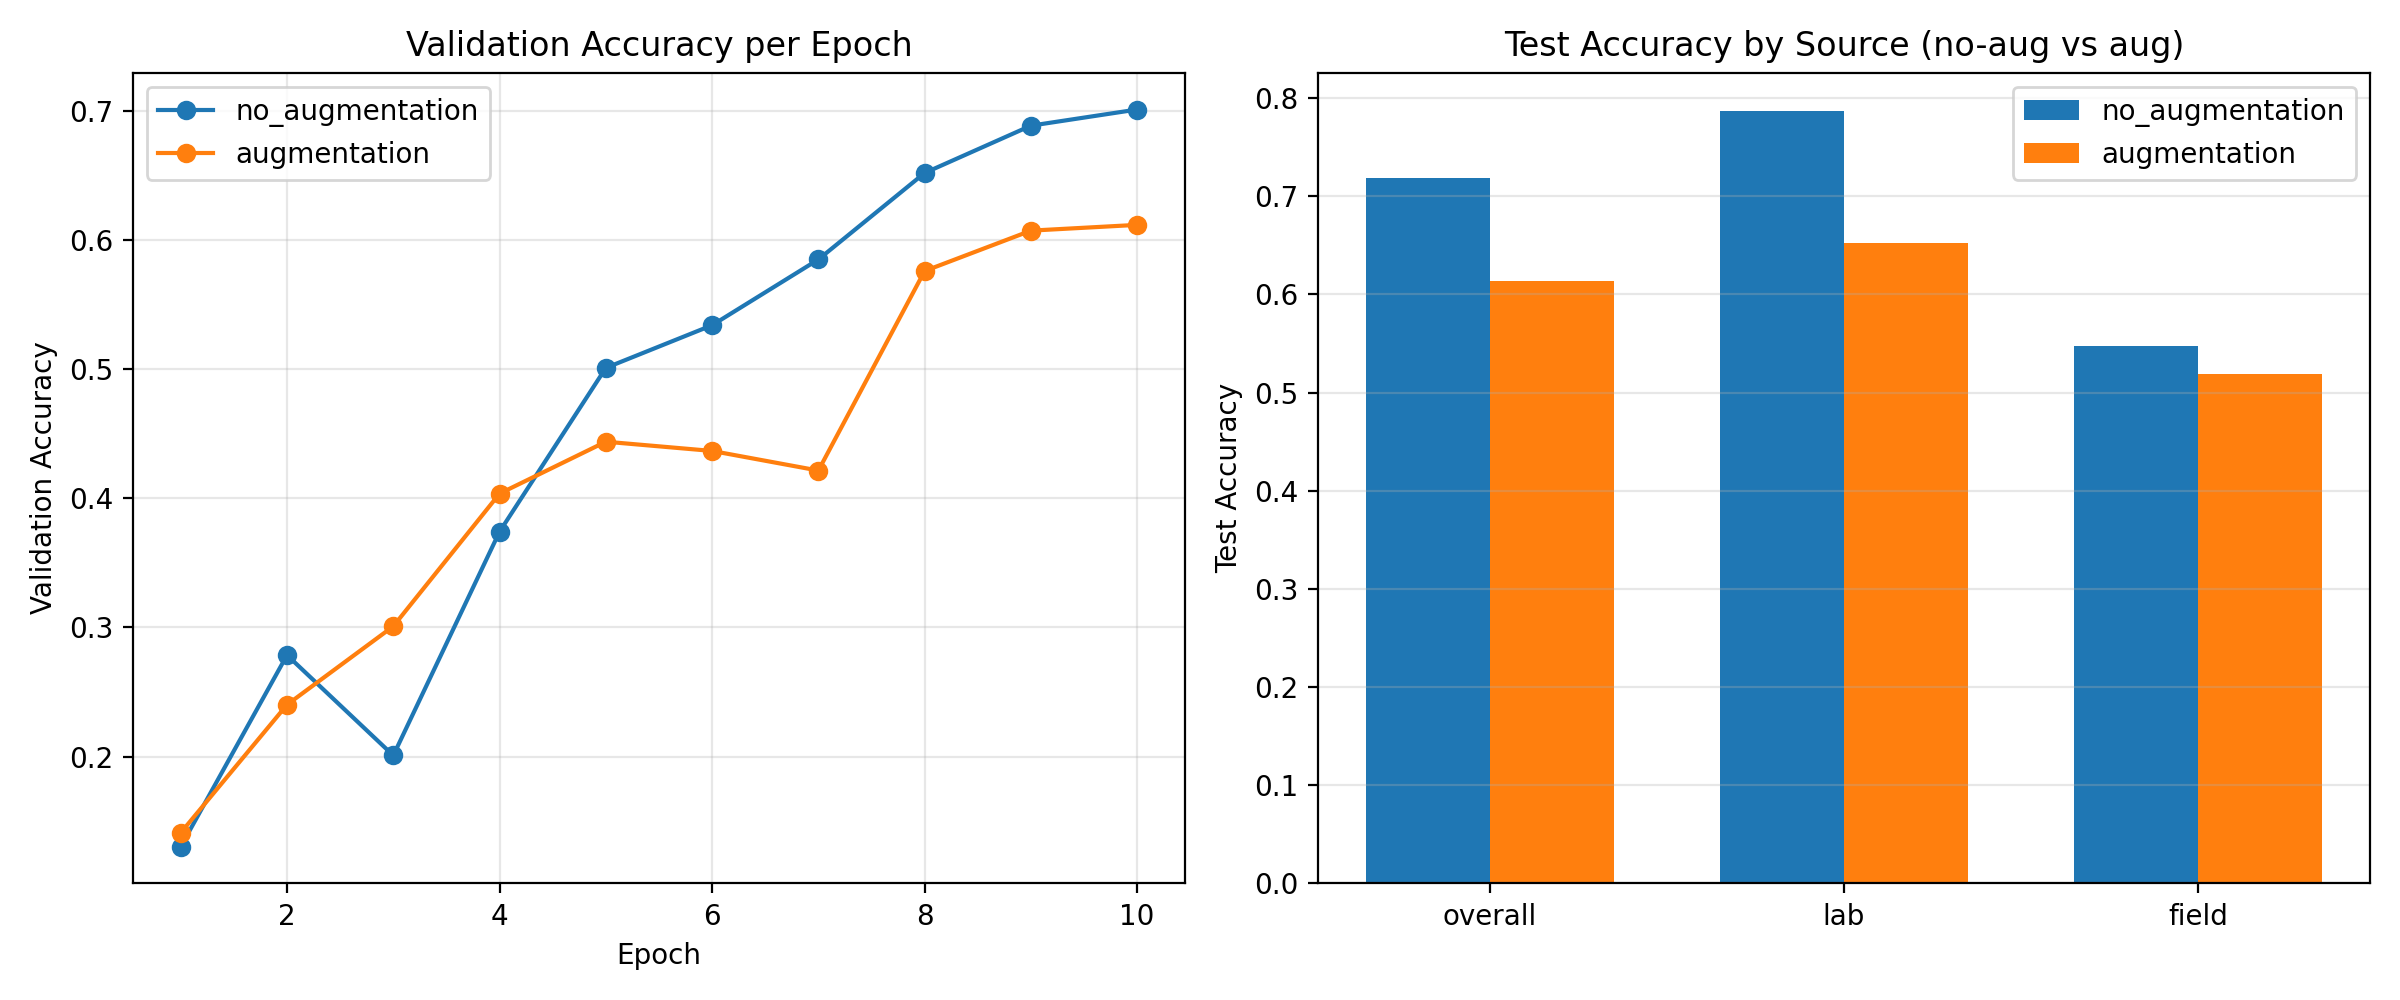

In [3]:
display(Image(filename=str(REPO_ROOT / "report/figures/data/augmentation_ablation.png")))

## Conclusion

With this controlled, short (10-epoch) budget, **augmentation did not help — it hurt every
metric**: overall test accuracy dropped from 71.8% (no augmentation) to 61.4% (augmentation),
macro-F1 dropped from 0.71 to 0.60, and even the `field` accuracy the augmentation is meant to
help with fell slightly (54.8% → 51.9%) rather than improving.

This is not evidence that augmentation is a bad idea for this dataset — it's evidence that random
crop / flip / brightness-contrast jitter makes each epoch's effective task harder, so the model
needs more epochs to reach the same point on the training curve, let alone benefit from the
regularisation. At 10 epochs the no-augmentation run has simply had an easier time fitting the
training distribution, and neither run has trained long enough for augmentation's generalisation
benefit to show up in the field numbers. The validation-accuracy curve above shows the
no-augmentation run pulling ahead almost immediately and staying there, rather than augmentation
catching up late — consistent with "not enough epochs yet" rather than "augmentation doesn't
help here."

Two things stand out that matter for the rest of the project, independent of the epoch-budget
caveat:

1. **Lab-to-field gap is large in both variants** (no-aug: 78.6% lab vs 54.8% field; aug: 65.2%
   lab vs 51.9% field). Both models generalise far worse to real-world field photos than to the
   controlled lab images, which is exactly the robustness problem this project is meant to
   address — worth flagging for the error-analysis / Grad-CAM stage (member 5).
2. **This ablation is only informative as a relative comparison at a fixed, short epoch budget.**
   Whoever runs the final, full-length Baseline training (more epochs, possibly a scheduler with
   more room to anneal) should not treat "augmentation=off" as the recommended setting — it
   should be re-checked once training runs long enough for both variants to converge before
   deciding whether augmentation is used in the final Baseline/MobileNetV2/ResNet18 configs.